# 03 — `GaussianFilter`: differentiable temporal smoothing

Convolves the last axis with a Gaussian kernel of size `6·sigma`
(±3 std). Larger `sigma` ⇒ stronger smoothing ⇒ more attenuation of
both noise and signal high-frequency content.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch

import scitex_nn

torch.manual_seed(0)
fs, seq_len = 256, 512
t = torch.arange(seq_len) / fs
clean = torch.sin(2 * torch.pi * 4 * t)
noisy = clean + 0.5 * torch.randn(seq_len)
x = noisy.view(1, 1, -1)

## Same noisy 4 Hz sine, three sigmas

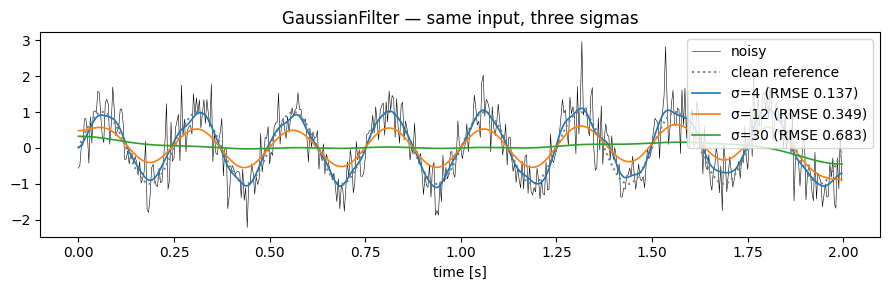

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(t.numpy(), noisy.numpy(), "k", lw=0.4, label="noisy")
ax.plot(t.numpy(), clean.numpy(), "grey", ls=":", label="clean reference")
for sigma in (4, 12, 30):
    y = scitex_nn.GaussianFilter(sigma=sigma)(x).squeeze().detach().numpy()
    rmse = ((y - clean.numpy()) ** 2).mean() ** 0.5
    ax.plot(t.numpy(), y, lw=1.2, label=f"σ={sigma} (RMSE {rmse:.3f})")
ax.legend(loc="upper right")
ax.set_xlabel("time [s]")
ax.set_title("GaussianFilter — same input, three sigmas")
fig.tight_layout()
plt.show()